<a href="https://colab.research.google.com/github/SpringBoard795/PicasoPhrase_Infosys_Internship_Nov2024/blob/MerajBegum/infosysproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [53]:
txt_dir='/content/drive/MyDrive/radiology/captions.txt'

In [54]:
import pandas as pd

In [55]:
txt_data=pd.read_table(txt_dir)

In [56]:
txt_data.head()
with open(txt_dir, 'r') as file:
  for i in range(0):
    print(file.readline().strip())

In [57]:
txt_data

,ROCO_00001,Axial MRI (coronal view).
0,ROCO_00006,Coronal plain computed tomography image showi...
1,ROCO_00016,Axial source image from an intracranial magne...
2,ROCO_00025,"The apical height, homogeneity, and the thick..."
3,ROCO_00031,CTO of RCA (closure in the 2nd segment)
4,ROCO_00036,Venography shows a large amount of thrombogen...
...,...,...
8173,ROCO_81771,Damus–Kaye–Stansel shunt. Oblique coronal MIP...
8174,ROCO_81778,"MRI pelvis post-radiation, axial STIR/T2W FSE..."
8175,ROCO_81792,Fluoroscopic image showing attempts to grab t...
8176,ROCO_81796,Positron emission tomography–computed tomogra...


In [58]:
caption=r'/content/drive/MyDrive/radiology/captions.txt'

In [59]:
df = pd.read_table(caption, header=None, names=['image_name', 'caption'])
print(df.head())

   image_name                                            caption
0  ROCO_00001                          Axial MRI (coronal view).
1  ROCO_00006   Coronal plain computed tomography image showi...
2  ROCO_00016   Axial source image from an intracranial magne...
3  ROCO_00025   The apical height, homogeneity, and the thick...
4  ROCO_00031            CTO of RCA (closure in the 2nd segment)


In [60]:
import numpy as np

In [61]:
random_captions = [
    "This is a beautiful image.",
    "A stunning scene captured perfectly.",
    "The colors in this image are vibrant.",
    "This picture tells a story.",
    "A captivating moment frozen in time."
]
num_samples = 100
captions = [np.random.choice(random_captions) for i in range(num_samples)]

In [62]:
num_samples=100

In [63]:
image_paths=[f"images/image_{i:03d}.jpg" for i in range(1,num_samples+1)]

In [64]:
captions=[np.random.choice(random_captions) for i in range(num_samples)]

In [65]:
df=pd.DataFrame({
    'image_path':image_paths,
    'caption':captions
})

In [66]:
df.head(10)

,image_path,caption
0,images/image_001.jpg,A captivating moment frozen in time.
1,images/image_002.jpg,This picture tells a story.
2,images/image_003.jpg,This is a beautiful image.
3,images/image_004.jpg,This picture tells a story.
4,images/image_005.jpg,A stunning scene captured perfectly.
5,images/image_006.jpg,A stunning scene captured perfectly.
6,images/image_007.jpg,This is a beautiful image.
7,images/image_008.jpg,The colors in this image are vibrant.
8,images/image_009.jpg,This picture tells a story.
9,images/image_010.jpg,A captivating moment frozen in time.


In [67]:
df['caption_length']=df['caption'].astype(str).apply(len)

In [68]:
df

,image_path,caption,caption_length
0,images/image_001.jpg,A captivating moment frozen in time.,36
1,images/image_002.jpg,This picture tells a story.,27
2,images/image_003.jpg,This is a beautiful image.,26
3,images/image_004.jpg,This picture tells a story.,27
4,images/image_005.jpg,A stunning scene captured perfectly.,36
...,...,...,...
95,images/image_096.jpg,This is a beautiful image.,26
96,images/image_097.jpg,A stunning scene captured perfectly.,36
97,images/image_098.jpg,A stunning scene captured perfectly.,36
98,images/image_099.jpg,A captivating moment frozen in time.,36


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   image_path      100 non-null    object
 1   caption         100 non-null    object
 2   caption_length  100 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [70]:
df['caption_length'].describe()

,caption_length
count,100.000000
mean,32.060000
std,4.947849
min,26.000000
25%,26.750000
50%,36.000000
75%,36.000000
max,37.000000


In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='caption_length', ylabel='Count'>

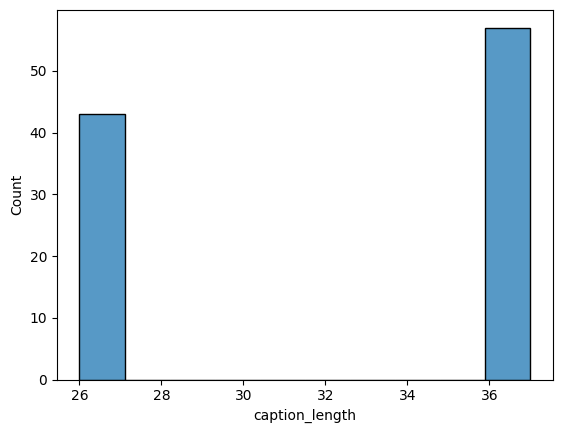

In [72]:
sns.histplot(df['caption_length'],bins=10)

<Axes: ylabel='caption_length'>

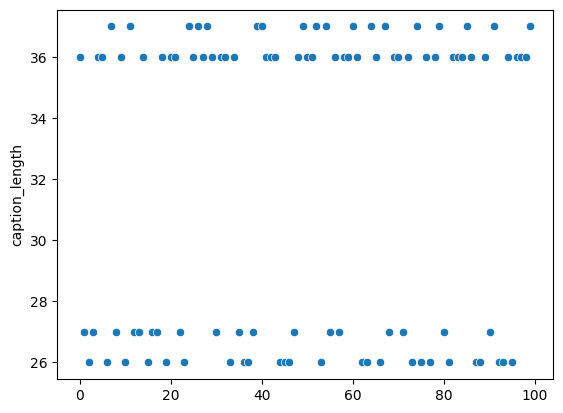

In [73]:
sns.scatterplot(df['caption_length'])

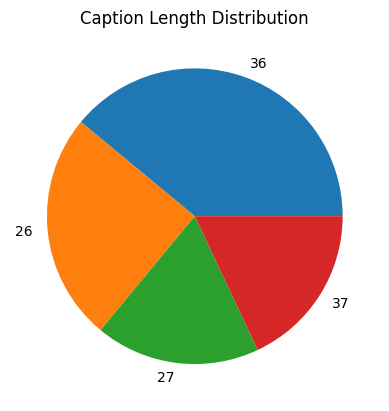

In [74]:
plt.pie(df['caption_length'].value_counts(), labels=df['caption_length'].value_counts().index)
plt.title('Caption Length Distribution')
plt.show()

In [75]:
from wordcloud import WordCloud

In [76]:
caption_text=''.join(df['caption'].astype(str))

In [77]:
wordcloud=WordCloud(width=800,height=400,max_words=50).generate(caption_text)

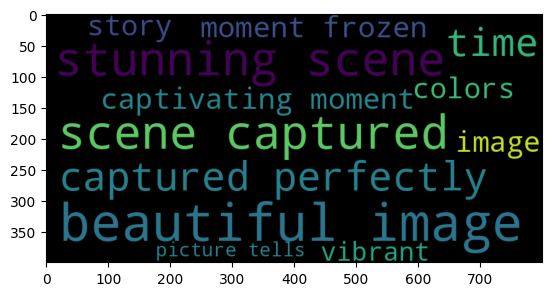

In [78]:
plt.imshow(wordcloud)

In [79]:
from google.colab import drive
drive._mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [80]:
img_dir='/content/drive/MyDrive/radiology/images'

In [81]:
import cv2
import numpy as np
import os

In [82]:
image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

In [83]:
image_files

['PMC5364092_cureus-0009-00000001052-i01.jpg',
 'PMC5368133_ymj-58-497-g002.jpg',
 'PMC5359432_CRIC2017-8507096.002.jpg',
 'PMC5352729_hp-29-77-g001.jpg',
 'PMC5361986_10.1177_2055116915610359-fig2.jpg',
 'PMC5367529_eor-1-160-g001.jpg',
 'PMC5385769_IJRI-27-23-g009.jpg',
 'PMC5340446_medi-96-e6185-g004.jpg',
 'PMC538289_1477-7819-2-38-1.jpg',
 'PMC5322422_CRIPE2017-7628946.002.jpg',
 'PMC5319117_12891_2017_1451_Fig4_HTML.jpg',
 'PMC5351361_LI-34-170-g003.jpg',
 'PMC5404152_JOCR-6-14-g002.jpg',
 'PMC5331846_EUS-6-61-g006.jpg',
 'PMC5398856_PAMJ-26-58-g001.jpg',
 'PMC5310263_gr7.jpg',
 'PMC5364109_ogs-60-232-g001.jpg',
 'PMC5394210_gr2.jpg',
 'PMC5318148_cureus-0009-00000000982-i01.jpg',
 'PMC5398644_10.1177_1179556517702853-fig4.jpg',
 'PMC5369920_medi-96-e6342-g002.jpg',
 'PMC5390922_10.1177_1179544117702866-fig5.jpg',
 'PMC5337315_CRIHEP2017-8567695.003.jpg',
 'PMC5371465_medi-96-e6379-g004.jpg',
 'PMC5341643_AER-11-17-g004.jpg',
 'PMC5393139_moj-9-061-f1b.jpg',
 'PMC5365271_gr1.jpg'

In [84]:
img_path=os.path.join(img_dir,image_files[0])
img_path1 = os.path.join(img_dir,image_files[7])
img_path2 = os.path.join(img_dir,image_files[177])

In [85]:
img_path
img_path1
img_path2

'/content/drive/MyDrive/radiology/images/PMC5449370_ahbps-21-88-g001.jpg'

In [86]:
img=cv2.imread(img_path)
img1=cv2.imread(img_path1)
img2=cv2.imread(img_path2)

array([[[253, 252, 254],
        [255, 254, 255],
        [251, 250, 252],
        ...,
        [246, 248, 248],
        [245, 247, 247],
        [246, 248, 248]],

       [[255, 254, 255],
        [251, 250, 252],
        [246, 245, 247],
        ...,
        [155, 157, 157],
        [161, 163, 163],
        [167, 169, 169]],

       [[253, 252, 254],
        [244, 243, 245],
        [237, 239, 240],
        ...,
        [ 13,  15,  15],
        [ 24,  26,  26],
        [ 35,  37,  37]],

       ...,

       [[246, 246, 246],
        [153, 153, 153],
        [ 11,  11,  11],
        ...,
        [129, 140, 144],
        [132, 141, 145],
        [135, 144, 148]],

       [[248, 248, 248],
        [163, 163, 163],
        [ 25,  25,  25],
        ...,
        [139, 150, 154],
        [141, 150, 154],
        [144, 153, 157]],

       [[247, 247, 247],
        [167, 167, 167],
        [ 35,  35,  35],
        ...,
        [152, 163, 167],
        [153, 162, 166],
        [156, 165, 169]]], dtype=uint8)
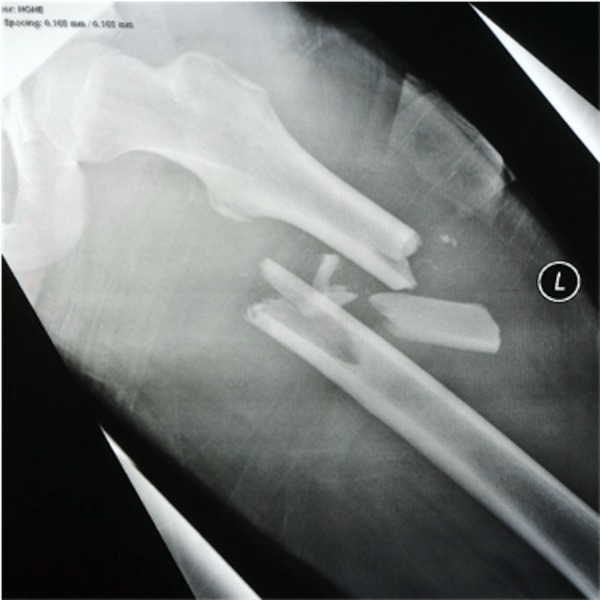

In [87]:
img

array([[[ 54,  54,  54],
        [ 54,  54,  54],
        [ 54,  54,  54],
        ...,
        [ 55,  55,  55],
        [ 46,  46,  46],
        [140, 140, 140]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  3,   3,   3],
        [  1,   1,   1],
        [101, 101, 101]],

       [[  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [  2,   2,   2],
        [  3,   3,   3],
        [109, 109, 109]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  1,   1,   1],
        [109, 109, 109]],

       [[  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [  0,   0,   0],
        [  4,   4,   4],
        [ 98,  98,  98]],

       [[106, 106, 106],
        [106, 106, 106],
        [106, 106, 106],
        ...,
        [106, 106, 106],
        [102, 102, 102],
        [175, 175, 175]]], dtype=uint8)
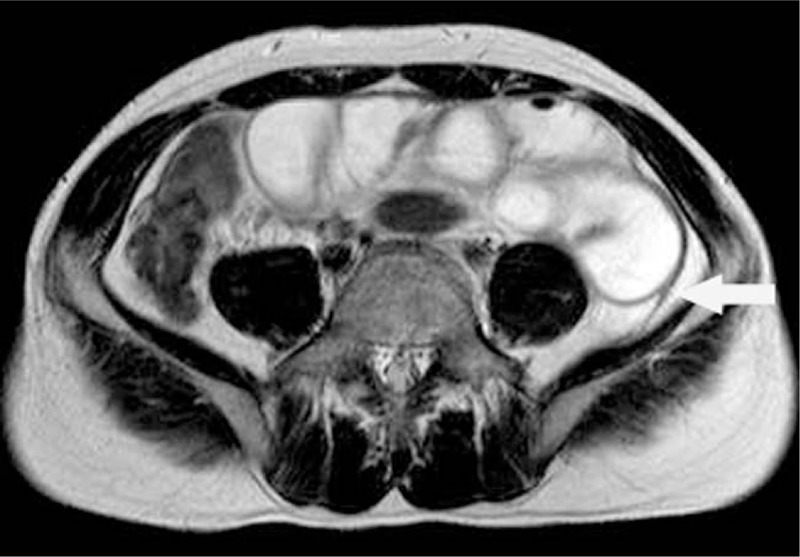

In [88]:
img1

array([[[54, 54, 54],
        [42, 42, 42],
        [44, 44, 44],
        ...,
        [44, 44, 44],
        [42, 41, 43],
        [54, 53, 55]],

       [[43, 43, 43],
        [20, 20, 20],
        [12, 12, 12],
        ...,
        [12, 12, 12],
        [20, 19, 21],
        [43, 42, 44]],

       [[45, 45, 45],
        [11, 11, 11],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [11, 10, 12],
        [45, 44, 46]],

       ...,

       [[45, 45, 45],
        [11, 11, 11],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [11, 10, 12],
        [45, 44, 46]],

       [[43, 43, 43],
        [20, 20, 20],
        [12, 12, 12],
        ...,
        [12, 12, 12],
        [20, 20, 20],
        [43, 43, 43]],

       [[54, 54, 54],
        [42, 42, 42],
        [44, 44, 44],
        ...,
        [44, 44, 44],
        [42, 42, 42],
        [54, 54, 54]]], dtype=uint8)
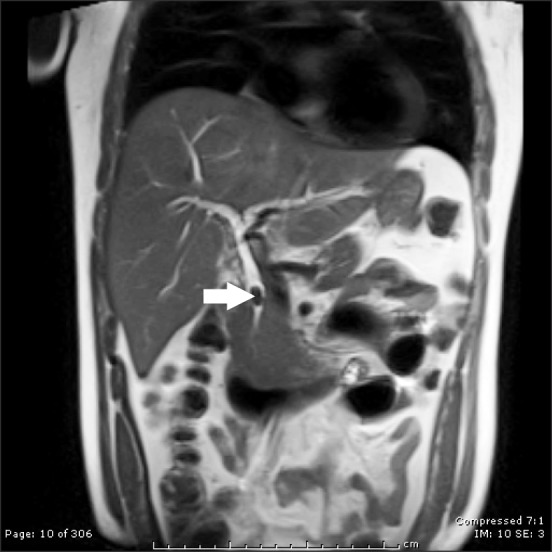

In [89]:
img2

In [90]:
img.shape

(600, 600, 3)

In [91]:
target_size=(244,244)

array([[[35, 35, 35],
        [24, 24, 24],
        [24, 24, 24],
        ...,
        [24, 24, 24],
        [24, 24, 24],
        [35, 34, 36]],

       [[23, 23, 23],
        [ 1,  1,  1],
        [ 1,  1,  1],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  1],
        [23, 22, 24]],

       [[24, 24, 24],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [24, 23, 25]],

       ...,

       [[24, 24, 24],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [24, 23, 25]],

       [[23, 23, 23],
        [ 1,  1,  1],
        [ 1,  1,  1],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  1],
        [23, 22, 24]],

       [[35, 35, 35],
        [24, 24, 24],
        [24, 24, 24],
        ...,
        [24, 24, 24],
        [24, 24, 24],
        [35, 35, 35]]], dtype=uint8)
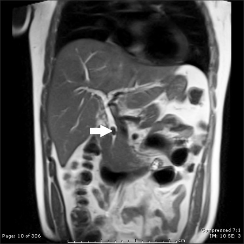

In [92]:
cv2.resize(img2,target_size)

In [93]:
img_processed=cv2.resize(img2,target_size)

In [94]:
img_normalized=img_processed/255.0

In [95]:
img_normalized

array([[[0.1372549 , 0.1372549 , 0.1372549 ],
        [0.09411765, 0.09411765, 0.09411765],
        [0.09411765, 0.09411765, 0.09411765],
        ...,
        [0.09411765, 0.09411765, 0.09411765],
        [0.09411765, 0.09411765, 0.09411765],
        [0.1372549 , 0.13333333, 0.14117647]],

       [[0.09019608, 0.09019608, 0.09019608],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        ...,
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.09019608, 0.08627451, 0.09411765]],

       [[0.09411765, 0.09411765, 0.09411765],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.09411765, 0.09019608, 0.09803922]],

       ...,

       [[0.09411765, 0.09411765, 0.09411765],
        [0.        , 0.        , 0.        ],
        [0.        , 0

In [96]:
img_gray = cv2.cvtColor(img_normalized.astype('uint8'), cv2.COLOR_BGR2GRAY)
img_eq=cv2.equalizeHist(img_gray)
print(f"Equalized Image(first 5 pixels): {img_eq[:5, :5]}")
img_denoised=cv2.GaussianBlur(img_eq, (5,5), 0)
print(f"Denoised Image(first 5 pixels): {img_denoised[:5, :5]}")

Equalized Image(first 5 pixels): [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Denoised Image(first 5 pixels): [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


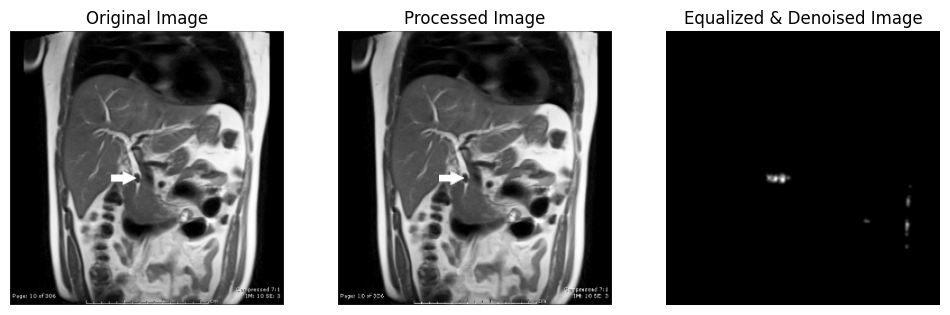

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
img_original=cv2.imread(img_path2)
plt.imshow(cv2.cvtColor(img_original,cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(img_processed.squeeze(),cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(img_denoised,cmap='gray')
plt.title("Equalized & Denoised Image")
plt.axis('off')
plt.show()

In [98]:
import tensorflow as tf

In [99]:
img2=np.expand_dims(img2,axis=0)

In [100]:
img2= img_processed.reshape(1, img_processed.shape[0], img_processed.shape[1], img_processed.shape[2])
datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=40, width_shift_range=0.2,height_shift_range=0.2, zoom_range=0.2,horizontal_flip=0.2)
it=datagen.flow(img2,batch_size=1)
augmented_images=[next(it)[0] for _ in range(5)]

In [101]:
augmented_images

[array([[[ 57.052036,  57.052036,  57.052036],
         [ 46.113686,  46.113686,  46.113686],
         [ 37.519955,  37.519955,  37.519955],
         ...,
         [ 35.      ,  35.      ,  35.      ],
         [ 35.      ,  35.      ,  35.      ],
         [ 35.      ,  35.      ,  35.      ]],
 
        [[ 56.72477 ,  56.72477 ,  56.72477 ],
         [ 45.833168,  45.833168,  45.833168],
         [ 37.3797  ,  37.3797  ,  37.3797  ],
         ...,
         [ 35.      ,  35.      ,  35.      ],
         [ 35.      ,  35.      ,  35.      ],
         [ 35.      ,  35.      ,  35.      ]],
 
        [[ 56.3975  ,  56.3975  ,  56.3975  ],
         [ 45.552654,  45.552654,  45.552654],
         [ 37.23944 ,  37.23944 ,  37.23944 ],
         ...,
         [ 35.      ,  35.      ,  35.      ],
         [ 35.      ,  35.      ,  35.      ],
         [ 35.      ,  35.      ,  35.      ]],
 
        ...,
 
        [[195.36581 , 195.36581 , 195.36581 ],
         [226.13873 , 226.13873 , 226.138

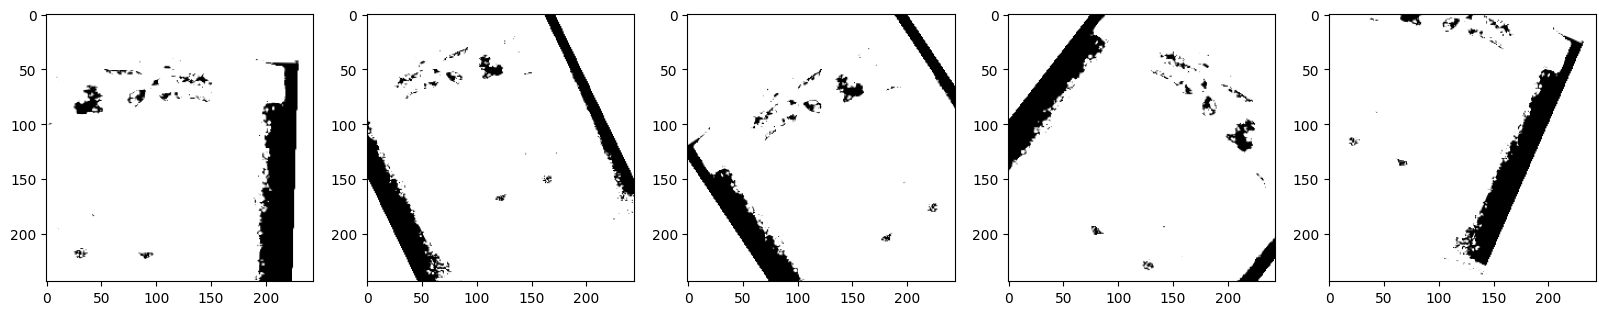

In [102]:
plt.figure(figsize=(20,5))
for i,aug_img in enumerate(augmented_images):
  plt.subplot(1,5,i+1)
  plt.imshow(aug_img)

In [103]:
corpus="""My mom taught me to finish everything on my plate at dinner.
The only problem with a pencil, is that they do not stay sharp long enough.
Our school building is made of bricks."""

In [104]:
print(corpus)

My mom taught me to finish everything on my plate at dinner.
The only problem with a pencil, is that they do not stay sharp long enough.
Our school building is made of bricks.


# ANN

In [105]:
df

,image_path,caption,caption_length
0,images/image_001.jpg,A captivating moment frozen in time.,36
1,images/image_002.jpg,This picture tells a story.,27
2,images/image_003.jpg,This is a beautiful image.,26
3,images/image_004.jpg,This picture tells a story.,27
4,images/image_005.jpg,A stunning scene captured perfectly.,36
...,...,...,...
95,images/image_096.jpg,This is a beautiful image.,26
96,images/image_097.jpg,A stunning scene captured perfectly.,36
97,images/image_098.jpg,A stunning scene captured perfectly.,36
98,images/image_099.jpg,A captivating moment frozen in time.,36


In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [107]:
tfidf=TfidfVectorizer(max_features=50)

In [108]:
X=tfidf.fit_transform(df['caption']).toarray()
y=df['caption_length']

In [109]:
X

array([[0.        , 0.        , 0.46778205, ..., 0.        , 0.46778205,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.30622106, 0.        ,
        0.        ],
       [0.        , 0.57716246, 0.        , ..., 0.3643619 , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.46778205, ..., 0.        , 0.46778205,
        0.        ],
       [0.43320065, 0.        , 0.        , ..., 0.24136032, 0.        ,
        0.43320065]])

In [110]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [111]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [113]:
model.fit(X,y,epochs=10)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0000e+00 - loss: -3.0835
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -7.3849  
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -11.6430 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -14.0571 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -20.5083 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -25.4258 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -30.1639 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -35.9482 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -43.3104 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -49.0543 


In [114]:
loss,accuracy=model.evaluate(X,y)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -57.2698  


In [115]:
loss,accuracy

(-58.149505615234375, 0.0)

In [116]:
model.predict(X)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([[0.8701473 ],
       [0.77557915],
       [0.8710063 ],
       [0.77557915],
       [0.87456894],
       [0.87456894],
       [0.8710063 ],
       [0.9010986 ],
       [0.77557915],
       [0.8701473 ],
       [0.8710063 ],
       [0.9010986 ],
       [0.77557915],
       [0.77557915],
       [0.8701473 ],
       [0.8710063 ],
       [0.77557915],
       [0.77557915],
       [0.8701473 ],
       [0.8710063 ],
       [0.87456894],
       [0.8701473 ],
       [0.77557915],
       [0.8710063 ],
       [0.9010986 ],
       [0.8701473 ],
       [0.9010986 ],
       [0.8701473 ],
       [0.9010986 ],
       [0.87456894],
       [0.7755791 ],
       [0.87456894],
       [0.8701473 ],
       [0.8710063 ],
       [0.8701473 ],
       [0.77557915],
       [0.8710063 ],
       [0.8710063 ],
       [0.77557915],
       [0.9010986 ],
       [0.9010986 ],
       [0.8701473 ],
       [0.8701473 ],
       [0.8701473 ],
       [0.8710063 ],
       [0.8710063 ],
       [0.8710063 ],
       [0.775

In [117]:
y

,caption_length
0,36
1,27
2,26
3,27
4,36
...,...
95,26
96,36
97,36
98,36


#VGG16 Feature Map Extraction


In [118]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [119]:
base_model=VGG16(weights='imagenet')

In [120]:
from tensorflow.keras.models import Model

In [121]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)

In [122]:
from tensorflow.keras.preprocessing import image

In [123]:
def load_and_preprocess_image(img_path,target_size=(224,224)):
  img=image.load_img(r"img_path",target_size=target_size)
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=preprocess_input(img_array)
  return img_array

In [124]:
img=image.load_img(img_path,target_size=(224,224))

In [125]:
img.size

(224, 224)

In [126]:
img_array=image.img_to_array(img)

In [127]:
img_array

array([[[252., 250., 251.],
        [243., 243., 241.],
        [245., 246., 241.],
        ...,
        [157., 157., 155.],
        [156., 156., 154.],
        [163., 163., 161.]],

       [[244., 243., 241.],
        [236., 235., 231.],
        [235., 234., 229.],
        ...,
        [  8.,   9.,   4.],
        [  9.,  10.,   5.],
        [ 24.,  24.,  22.]],

       [[238., 234., 231.],
        [217., 214., 209.],
        [212., 209., 204.],
        ...,
        [  9.,  10.,   5.],
        [  8.,   9.,   4.],
        [ 27.,  28.,  23.]],

       ...,

       [[156., 156., 154.],
        [  7.,   7.,   7.],
        [  7.,   5.,   6.],
        ...,
        [137., 133., 122.],
        [128., 124., 113.],
        [129., 125., 114.]],

       [[154., 154., 154.],
        [  8.,   8.,   8.],
        [  6.,   4.,   7.],
        ...,
        [150., 146., 135.],
        [139., 135., 124.],
        [141., 137., 126.]],

       [[163., 163., 163.],
        [ 23.,  23.,  23.],
        [ 25.,  

In [128]:
import numpy as np
img_array=np.expand_dims(img_array,axis=0)

In [129]:
img_array=preprocess_input(img_array)

In [130]:
img_array

array([[[[ 147.061    ,  133.22101  ,  128.32     ],
         [ 137.061    ,  126.221    ,  119.32     ],
         [ 137.061    ,  129.22101  ,  121.32     ],
         ...,
         [  51.060997 ,   40.221    ,   33.32     ],
         [  50.060997 ,   39.221    ,   32.32     ],
         [  57.060997 ,   46.221    ,   39.32     ]],

        [[ 137.061    ,  126.221    ,  120.32     ],
         [ 127.061    ,  118.221    ,  112.32     ],
         [ 125.061    ,  117.221    ,  111.32     ],
         ...,
         [ -99.939    , -107.779    , -115.68     ],
         [ -98.939    , -106.779    , -114.68     ],
         [ -81.939    ,  -92.779    ,  -99.68     ]],

        [[ 127.061    ,  117.221    ,  114.32     ],
         [ 105.061    ,   97.221    ,   93.32     ],
         [ 100.061    ,   92.221    ,   88.32     ],
         ...,
         [ -98.939    , -106.779    , -114.68     ],
         [ -99.939    , -107.779    , -115.68     ],
         [ -80.939    ,  -88.779    ,  -96.68     ]],

In [131]:
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step


In [132]:
n_features=feature_map.shape[-1]

In [133]:
n_features

512

In [134]:
size=feature_map.shape[1]

In [135]:
from PIL import Image

In [136]:
img=Image.open(img_path)

In [137]:
img.size

(600, 600)

In [138]:
display_grid=np.zeros((size,size*n_features))

In [139]:
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [140]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [141]:
scale=20./n_features

In [142]:
import matplotlib.pyplot as plt

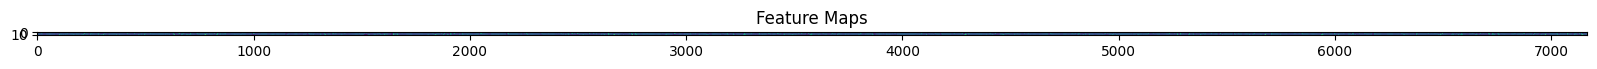

In [143]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

In [144]:
import tensorflow as tf

In [145]:
base_model=tf.keras.applications.ResNet50(weights="imagenet",include_top=False)
base_model.trainable=False

In [146]:
img=tf.keras.preprocessing.image.load_img(img_path,target_size=(224,224))

In [147]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [148]:
img_array.shape

(1, 224, 224, 3)

In [149]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)

In [150]:
img_array.shape

(1, 224, 224, 3)

In [151]:
img_array

array([[[[ 147.061    ,  133.22101  ,  128.32     ],
         [ 137.061    ,  126.221    ,  119.32     ],
         [ 137.061    ,  129.22101  ,  121.32     ],
         ...,
         [  51.060997 ,   40.221    ,   33.32     ],
         [  50.060997 ,   39.221    ,   32.32     ],
         [  57.060997 ,   46.221    ,   39.32     ]],

        [[ 137.061    ,  126.221    ,  120.32     ],
         [ 127.061    ,  118.221    ,  112.32     ],
         [ 125.061    ,  117.221    ,  111.32     ],
         ...,
         [ -99.939    , -107.779    , -115.68     ],
         [ -98.939    , -106.779    , -114.68     ],
         [ -81.939    ,  -92.779    ,  -99.68     ]],

        [[ 127.061    ,  117.221    ,  114.32     ],
         [ 105.061    ,   97.221    ,   93.32     ],
         [ 100.061    ,   92.221    ,   88.32     ],
         ...,
         [ -98.939    , -106.779    , -114.68     ],
         [ -99.939    , -107.779    , -115.68     ],
         [ -80.939    ,  -88.779    ,  -96.68     ]],

In [152]:
feature_map=base_model(img_array)

In [153]:
feature_map.shape

TensorShape([1, 7, 7, 2048])

# ANN

In [154]:
import pandas as pd

In [155]:
data={
    "Title": [
        "Breaking news: COVID-19 vaccine is a scam!",
        "NASA discovers new planet with signs of life",
        "Fake celebrity dies in car crash story circulates",
        "New study confirms coffee boosts productivity"
    ],
    "Label": [1, 0, 1, 0]  # 1 = Fake, 0 = Real
}

In [156]:
df=pd.DataFrame(data)

In [157]:
df

,Title,Label
0,Breaking news: COVID-19 vaccine is a scam!,1
1,NASA discovers new planet with signs of life,0
2,Fake celebrity dies in car crash story circulates,1
3,New study confirms coffee boosts productivity,0


In [158]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [159]:
tfidf=TfidfVectorizer(max_features=50)

In [160]:
X=tfidf.fit_transform(df['Title']).toarray()
y=df['Label']

In [161]:
X

array([[0.37796447, 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.37796447,
        0.        , 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.37796447, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.36222393, 0.        , 0.        , 0.        ,
        0.36222393, 0.36222393, 0.2855815 , 0.        , 0.36222393,
        0.36222393, 0.        , 0.        , 0.36222393, 0.        ,
        0.        , 0.        , 0.36222393],
       [0.        , 0.        , 0.        , 0.35355339, 0.35355339,
        0.35355339, 0.        , 0.        , 0.        , 0.35355339,
        0.35355339, 0.        , 0.35355339, 0.35355339, 0.        ,
        0.        , 0.    

In [162]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [163]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [164]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [165]:
model.fit(X,y,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6996
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 0.7463
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.7429
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 0.7925
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7500 - loss: 0.6854
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 0.6896
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.7225
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 0.6962
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2500 - loss: 0.7482
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.7047


In [166]:
loss,accuracy=model.evaluate(X,y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5000 - loss: 0.6742


In [167]:
loss,accuracy

(0.6741586923599243, 0.5)

In [168]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[0.5179724 ],
       [0.509258  ],
       [0.55052346],
       [0.5181291 ]], dtype=float32)

In [169]:
y

,Label
0,1
1,0
2,1
3,0


#RNN

In [170]:
!pip install faker

In [171]:
from faker import Faker

In [172]:
import numpy as np

In [173]:
fake=Faker()
Faker.seed(42)

In [174]:
def generate_text_labels(num_samples=5000):
  text=[fake.sentence(nb_words=10) for i in range(num_samples)]
  labels=np.random.randint(0,2,num_samples)
  return text,labels

In [175]:
text,labels=generate_text_labels()

In [176]:
text

['Agent every development say quality throughout beautiful.',
 'All behavior discussion own night respond red information last everything thank.',
 'Recently future choice whatever from behavior benefit suggest.',
 'Enough analysis least by two bad fall pick those gun court attorney product.',
 'World talk term herself law street class great prove.',
 'Participant commercial rock clear here writer.',
 'Detail food shoulder argue start source husband at tree note responsibility defense material.',
 'Central cause seat much section investment on gun young catch management.',
 'Technology check civil quite others his.',
 'You more wife team activity result race Mr environment political born itself law.',
 'Will seven medical blood personal success medical current hear.',
 'Much single morning a food affect upon these.',
 'Dream drive note bad rule staff within mouth call.',
 'Water close month parent who up sense ready require human public health.',
 'Later easy ask again network open acc

In [177]:
labels

array([0, 1, 1, ..., 0, 1, 1])

In [178]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [179]:
tokenizer=Tokenizer(num_words=5000)

In [180]:
tokenizer.fit_on_texts(text)

In [181]:
sequences=tokenizer.texts_to_sequences(text)

In [182]:
sequences

[[738, 228, 739, 821, 378, 191, 650],
 [330, 29, 379, 487, 192, 782, 229, 740, 282, 42, 822],
 [230, 30, 331, 117, 741, 29, 231, 22],
 [651, 91, 283, 590, 284, 118, 285, 652, 119, 120, 783, 784, 332],
 [424, 193, 23, 425, 16, 43, 785, 426, 742],
 [333, 956, 286, 121, 334, 743],
 [957, 696, 92, 335, 653, 75, 122, 427, 428, 76, 591, 232, 194],
 [592, 233, 915, 697, 336, 593, 698, 120, 429, 123, 699],
 [744, 870, 700, 195, 337, 338],
 [5, 60, 44, 594, 339, 234, 488, 287, 288, 31, 654, 289, 16],
 [538, 430, 340, 61, 290, 235, 340, 952, 786],
 [697, 45, 964, 431, 696, 871, 936, 432],
 [380, 291, 76, 118, 823, 787, 152, 539, 341],
 [46, 655, 489, 32, 656, 196, 24, 197, 342, 788, 153, 236],
 [490, 491, 492, 62, 595, 824, 343, 745, 237, 2, 330, 596],
 [540, 292, 238, 433, 825, 124, 344, 541, 542, 77, 434, 381],
 [154, 78, 8, 701, 493, 382, 286, 345, 597, 783, 890],
 [33, 42, 63, 746, 383, 744, 93],
 [543, 155, 916, 29, 747, 702],
 [494, 657, 122, 198, 598, 424, 435, 541, 293, 294, 117],
 [332,

In [183]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences=pad_sequences(sequences,maxlen=20)

In [184]:
padded_sequences[:2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        738, 228, 739, 821, 378, 191, 650],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 330,  29, 379, 487,
        192, 782, 229, 740, 282,  42, 822]], dtype=int32)

In [185]:
train_size=int(0.8*len(padded_sequences))

In [186]:
train_size

4000

In [187]:
X_train,X_test=padded_sequences[:train_size],padded_sequences[train_size:]
y_train,y_test=labels[:train_size],labels[train_size:]

In [188]:
X_train

array([[  0,   0,   0, ..., 378, 191, 650],
       [  0,   0,   0, ..., 282,  42, 822],
       [  0,   0,   0, ...,  29, 231,  22],
       ...,
       [  0,   0,   0, ..., 220, 935, 730],
       [  0,   0,   0, ..., 734, 649, 361],
       [  0,   0,   0, ...,   6,  63, 515]], dtype=int32)

In [189]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [190]:
model=Sequential([Embedding(input_dim=5000,output_dim=64,input_length=20),
                  SimpleRNN(64,return_sequences=False),
                  Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [191]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [192]:
model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.4996 - loss: 0.6985 - val_accuracy: 0.4863 - val_loss: 0.6945
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7955 - loss: 0.5797 - val_accuracy: 0.4963 - val_loss: 0.8262
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9151 - loss: 0.2619 - val_accuracy: 0.4675 - val_loss: 1.3082
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9808 - loss: 0.0895 - val_accuracy: 0.4800 - val_loss: 1.8388
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9976 - loss: 0.0228 - val_accuracy: 0.4975 - val_loss: 2.1977
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.4837 - val_loss: 2.4777
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.4825 - val_loss: 2.6375
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 1.0000 - loss: 0.0014 - val_acc

In [193]:
model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[9.93701339e-01],
       [1.53985253e-04],
       [4.33618901e-03],
       [6.56555176e-01],
       [2.12557032e-03],
       [9.46659818e-02],
       [3.21752310e-01],
       [4.62042391e-02],
       [9.99948025e-01],
       [1.22204743e-04],
       [9.34039891e-01],
       [9.99302328e-01],
       [6.15233730e-04],
       [9.95613992e-01],
       [4.62919503e-01],
       [7.73792326e-01],
       [9.62572396e-01],
       [2.81282008e-01],
       [9.99653041e-01],
       [6.80010676e-01],
       [1.12177566e-01],
       [5.29616237e-01],
       [9.66940641e-01],
       [9.98705566e-01],
       [3.43463995e-04],
       [9.16479468e-01],
       [9.94706035e-01],
       [4.05838341e-03],
       [8.42599780e-04],
       [2.42725855e-05],
       [9.13399041e-01],
       [9.95327652e-01],
       [9.99966085e-01],
       [6.84387684e-01],
       [2.34436579e-02],
       [9.99210000e-01],
       [9.93993342e-01],
       [9.99956727e-01],
       [9.99993086e-01],
       [9.47274148e-01],


#LSTM

In [194]:
!pip install faker


In [195]:
from faker import Faker
import random

In [196]:
fake=Faker()

In [197]:
texts=[]
labels=[]
num_samples=2000
for i in range(num_samples):
  if random.random()>0.5:
    texts.append(fake.text(max_nb_chars=50))
    labels.append(1)
  else:
    texts.append(fake.text(max_nb_chars=50))
    labels.append(0)

In [198]:
train_texts=texts[:1600]
test_texts=texts[1600:]
train_labels=labels[:1600]
test_labels=labels[1600:]

In [199]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [200]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(train_texts)

In [201]:
train_sequences=tokenizer.texts_to_sequences(train_texts)
test_sequences=tokenizer.texts_to_sequences(test_texts)

In [202]:
train_sequences

[[413, 127, 542, 543, 25],
 [200, 414, 201, 8, 82, 415],
 [26, 544, 302, 128, 416, 656],
 [303, 779, 545, 202, 780, 83, 546],
 [304, 203, 305, 657, 417, 204],
 [418, 870, 547, 419, 658, 306, 420],
 [659, 660, 421, 307, 661, 781, 27],
 [48, 18, 422, 548, 418, 19],
 [308, 549, 205, 28],
 [20, 550, 206],
 [309, 423, 49],
 [551, 207, 84, 128, 782, 208],
 [209, 1, 50, 424, 547],
 [425, 310, 311, 85, 210, 426],
 [312, 552, 86, 29, 553, 51],
 [129, 662, 313, 554, 130, 30],
 [52, 211, 87, 783, 31],
 [131, 426, 663, 132, 555, 212],
 [314, 871, 423, 315, 88, 89, 9, 2],
 [316, 53, 664, 784, 551, 317],
 [556, 28, 557, 785, 213, 54, 427, 90],
 [214, 205, 215, 216, 318, 428, 217],
 [558, 218, 91, 219, 429, 203],
 [55, 133, 786, 220],
 [430, 665, 221, 666],
 [559, 32, 134, 555, 208, 215],
 [560, 561, 48, 319, 48, 320, 222],
 [206, 135, 321, 136, 10],
 [92, 787, 223, 224, 431, 213, 202],
 [27, 432, 433, 562, 56],
 [667, 21, 57, 137, 2, 788],
 [31, 668, 789, 82, 138, 790, 434],
 [435, 5, 225, 563, 139,

In [203]:
word_index=tokenizer.word_index

In [204]:
max_sequence_length=max(len(seq) for seq in train_sequences)

In [205]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [206]:
max_sequence_length

10

In [207]:
train_padded=pad_sequences(train_sequences,maxlen=max_sequence_length,padding="post")
test_padded=pad_sequences(test_sequences,maxlen=max_sequence_length,padding="post")

In [208]:
test_padded

array([[223, 850, 703, ...,   0,   0,   0],
       [547, 701, 521, ...,   0,   0,   0],
       [834, 446, 588, ...,   0,   0,   0],
       ...,
       [654, 391, 895, ...,   0,   0,   0],
       [806, 751, 353, ...,   0,   0,   0],
       [178,  26, 774, ...,   0,   0,   0]], dtype=int32)

In [209]:
from tensorflow.keras.utils import to_categorical

In [210]:
train_labels=to_categorical(train_labels)
test_labels=to_categorical(test_labels)

In [217]:
train_labels

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [218]:
from gensim.models import Word2Vec
w2v_model=Word2Vec(sentences=[text.split() for text in train_texts],vector_size=100)

In [219]:
import numpy as np

In [220]:
embedding_dim=100
embedding_matrix=np.zeros((len(word_index)+1,embedding_dim))

In [221]:
for word,i in word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i]=w2v_model.wv[word]

In [222]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.00120831, -0.00188889, -0.0016321 , ...,  0.00069408,
        -0.00820131, -0.0049158 ],
       [ 0.00477591,  0.00678351, -0.00792454, ...,  0.00042261,
        -0.00538835, -0.00603175],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [223]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        LSTM(128),
        Dense(2,activation="softmax")
])

In [224]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [225]:
model.fit(train_padded,train_labels,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.4951 - loss: 0.6938 - val_accuracy: 0.5125 - val_loss: 0.6931
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5148 - loss: 0.6932 - val_accuracy: 0.4875 - val_loss: 0.6934
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5211 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4860 - loss: 0.6932 - val_accuracy: 0.5344 - val_loss: 0.6931
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5043 - loss: 0.6932 - val_accuracy: 0.4875 - val_loss: 0.6933
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5209 - loss: 0.6924 - val_accuracy: 0.5188 - val_loss: 0.6924
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5282 - loss: 0.6903 - val_accuracy: 0.4938 - val_loss: 0.6995
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5364 - loss: 0.6860 - val_accuracy: 0.4969 - v

In [226]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4815 - loss: 0.7213


In [227]:
test_accuracy

0.5199999809265137

#Bidirectional

In [228]:
from tensorflow.keras.layers import Bidirectional
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        Bidirectional(LSTM(128)),
        Dense(2,activation="softmax")
])

#Stacked LSTM

In [229]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        LSTM(128),
        LSTM(64),
        Dense(2,activation="softmax")
])

##Dropout LSTM

In [230]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        LSTM(128,dropout=0.2,),
        Dense(2,activation="softmax")
])

##GRU

In [231]:
texts = [
    "The quick brown fox jumps over the lazy dog",
    "GRU models are great for sequential data",
    "Deep learning models can process large amounts of text data",
    "This is an example of large text data for text prediction tasks",
    "Machine learning and natural language processing are key areas of AI",
    "Artificial intelligence is transforming industries",
    "Natural language processing is a branch of AI",
    "Deep learning techniques enable computers to understand images and text",
    "Sequence models like RNN and GRU are effective for time series data",
    "The future of AI relies on the integration of machine learning and big data",
    "Big data and AI are driving innovation across various sectors",
    "Language models are used in translation and sentiment analysis tasks",
    "Understanding context is crucial in natural language understanding",
    "Neural networks are designed to recognize patterns in large datasets",
]
categories = [0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 0, 1, 2, 0] # 0->postive 1->negative 2->neutral

In [232]:
tokenizer=Tokenizer(num_words=1000)
tokenizer.fit_on_texts(texts)
sequences=tokenizer.texts_to_sequences(texts)

In [233]:
max_length=max(len(seq) for seq in sequences)
max_length

14

In [234]:
padded_sequences=pad_sequences(sequences,maxlen=max_length,padding="post")

In [235]:
num_classes=3
categorical_labels=to_categorical(categories,num_classes)

In [236]:
categorical_labels

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [237]:
embedding_dim=64


In [238]:
from tensorflow.keras.layers import GRU
model=Sequential([
    Embedding(input_dim=1000,output_dim=embedding_dim,input_length=max_length),
    GRU(128,dropout=0.2),
    Dense(num_classes,activation="softmax")
])

In [239]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=['accuracy'])

In [240]:
model.fit(padded_sequences,categorical_labels,epochs=14)

Epoch 1/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2857 - loss: 1.0911
Epoch 2/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4286 - loss: 1.0809
Epoch 3/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4286 - loss: 1.0783
Epoch 4/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4286 - loss: 1.0744
Epoch 5/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4286 - loss: 1.0653
Epoch 6/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4286 - loss: 1.0664
Epoch 7/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4286 - loss: 1.0622
Epoch 8/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4286 - loss: 1.0569
Epoch 9/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4286 - loss: 1.0577
Epoch 10/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4286 - loss: 1.0562
Epoch 11/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4286 - loss: 1.0556
Epoch 12/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 1.0491
Epo

#LSTM Text Generation

In [241]:
corpus="""The quick brown fox jumps over the lazy dog",
    "GRU models are great for sequential data",
    "Deep learning models can process large amounts of text data",
    "This is an example of large text data for text prediction tasks",
    "Machine learning and natural language processing are key areas of AI",
    "Artificial intelligence is transforming industries",
    "Natural language processing is a branch of AI",
    "Deep learning techniques enable computers to understand images and text",
    "Sequence models like RNN and GRU are effective for time series data",
    "The future of AI relies on the integration of machine learning and big data",
    "Big data and AI are driving innovation across various sectors",
    "Language models are used in translation and sentiment analysis tasks",
    "Understanding context is crucial in natural language understanding",
    "Neural networks are designed to recognize patterns in large datasets"""

In [242]:
tokenizer.fit_on_texts([corpus])

In [243]:
vocab_size=len(tokenizer.word_index)+1
vocab_size

80

In [244]:
sequences=[]

In [245]:
for line in corpus.split("\n"):
  token_list=tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    ngram_sequence=token_list[:i+1]
    sequences.append(ngram_sequence)

In [246]:
sequences

[[5, 24],
 [5, 24, 25],
 [5, 24, 25, 26],
 [5, 24, 25, 26, 27],
 [5, 24, 25, 26, 27, 28],
 [5, 24, 25, 26, 27, 28, 5],
 [5, 24, 25, 26, 27, 28, 5, 29],
 [5, 24, 25, 26, 27, 28, 5, 29, 30],
 [16, 6],
 [16, 6, 1],
 [16, 6, 1, 31],
 [16, 6, 1, 31, 12],
 [16, 6, 1, 31, 12, 32],
 [16, 6, 1, 31, 12, 32, 2],
 [17, 7],
 [17, 7, 6],
 [17, 7, 6, 33],
 [17, 7, 6, 33, 34],
 [17, 7, 6, 33, 34, 13],
 [17, 7, 6, 33, 34, 13, 35],
 [17, 7, 6, 33, 34, 13, 35, 3],
 [17, 7, 6, 33, 34, 13, 35, 3, 8],
 [17, 7, 6, 33, 34, 13, 35, 3, 8, 2],
 [36, 9],
 [36, 9, 37],
 [36, 9, 37, 38],
 [36, 9, 37, 38, 3],
 [36, 9, 37, 38, 3, 13],
 [36, 9, 37, 38, 3, 13, 8],
 [36, 9, 37, 38, 3, 13, 8, 2],
 [36, 9, 37, 38, 3, 13, 8, 2, 12],
 [36, 9, 37, 38, 3, 13, 8, 2, 12, 8],
 [36, 9, 37, 38, 3, 13, 8, 2, 12, 8, 39],
 [36, 9, 37, 38, 3, 13, 8, 2, 12, 8, 39, 18],
 [19, 7],
 [19, 7, 4],
 [19, 7, 4, 14],
 [19, 7, 4, 14, 10],
 [19, 7, 4, 14, 10, 20],
 [19, 7, 4, 14, 10, 20, 1],
 [19, 7, 4, 14, 10, 20, 1, 40],
 [19, 7, 4, 14, 10, 20,

In [247]:
max_sequence_len=max([len(seq) for seq in sequences])

In [248]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
sequences=pad_sequences(sequences,maxlen=max_sequence_len,padding="pre")

In [249]:
sequences

array([[ 0,  0,  0, ...,  0,  5, 24],
       [ 0,  0,  0, ...,  5, 24, 25],
       [ 0,  0,  0, ..., 24, 25, 26],
       ...,
       [ 0,  0,  0, ..., 77, 78, 15],
       [ 0,  0,  0, ..., 78, 15, 13],
       [ 0,  0,  0, ..., 15, 13, 79]], dtype=int32)

In [250]:
from tensorflow.keras.utils import to_categorical
X=sequences[:,:-1]
y=sequences[:,-1]
y=to_categorical(y,num_classes=vocab_size)

In [251]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
model=Sequential([
    Embedding(vocab_size,50,input_length=max_sequence_len-1),
    LSTM(100,return_sequences=False),
    Dense(vocab_size,activation="softmax")

])

In [252]:
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

In [253]:
model.fit(X,y,epochs=100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0180 - loss: 4.3829
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0892 - loss: 4.3711
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0946 - loss: 4.3569
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0878 - loss: 4.3308
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0616 - loss: 4.2747
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0427 - loss: 4.1933
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0572 - loss: 4.1602
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0457 - loss: 4.0950
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0520 - loss: 4.0292
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0826 - loss: 4.0305
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0837 - loss: 4.0372
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0966 - lo

In [254]:
import numpy as np
def generate_text(seed_text,next_words,max_sequence_len):
  for _ in range(next_words):
    token_list=tokenizer.texts_to_sequences([seed_text])[0]
    token_list=pad_sequences([token_list],maxlen=max_sequence_len-1,padding="pre")
    predicted=np.argmax(model.predict(token_list,verbose=0),axis=-1)
    output_word=""
    for word,index in tokenizer.word_index.items():
      if index==predicted:
        output_word=word
        break
    seed_text+=" "+output_word
  return seed_text

In [255]:
seed_text="AI is"
generate_text(seed_text,next_words=5,max_sequence_len=max_sequence_len)

'AI is is ai ai of the'

#Final Image Captioning

In [256]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Add
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
import pickle
from tensorflow.keras.layers import Input, Dropout, Add
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [257]:
image_path="/content/drive/MyDrive/radiology/images"
caption_path="/content/drive/MyDrive/radiology/captions.txt"

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


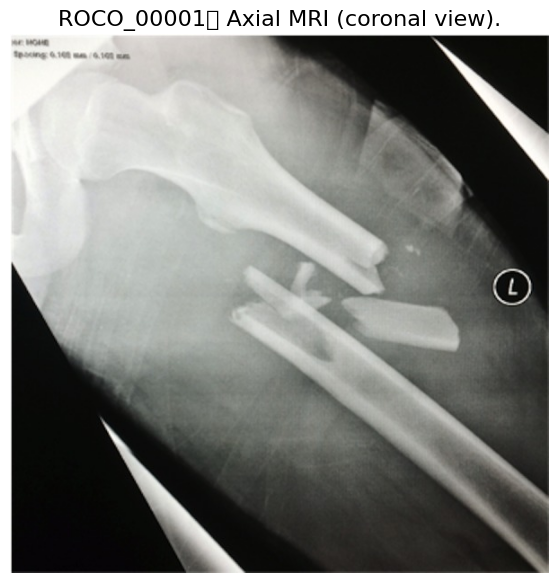

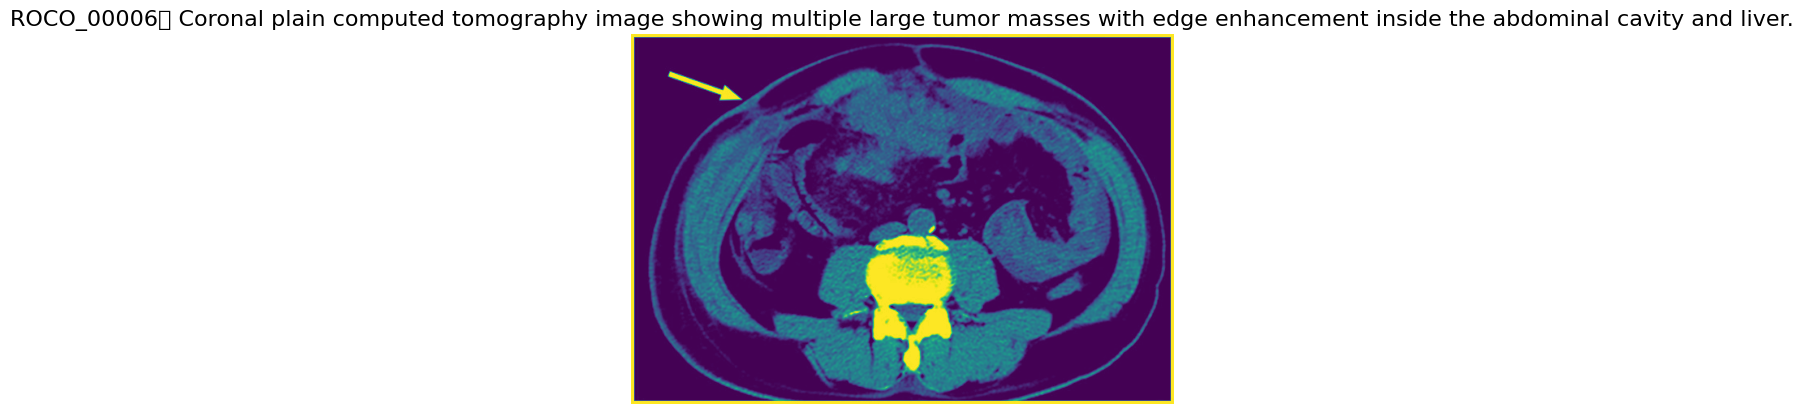

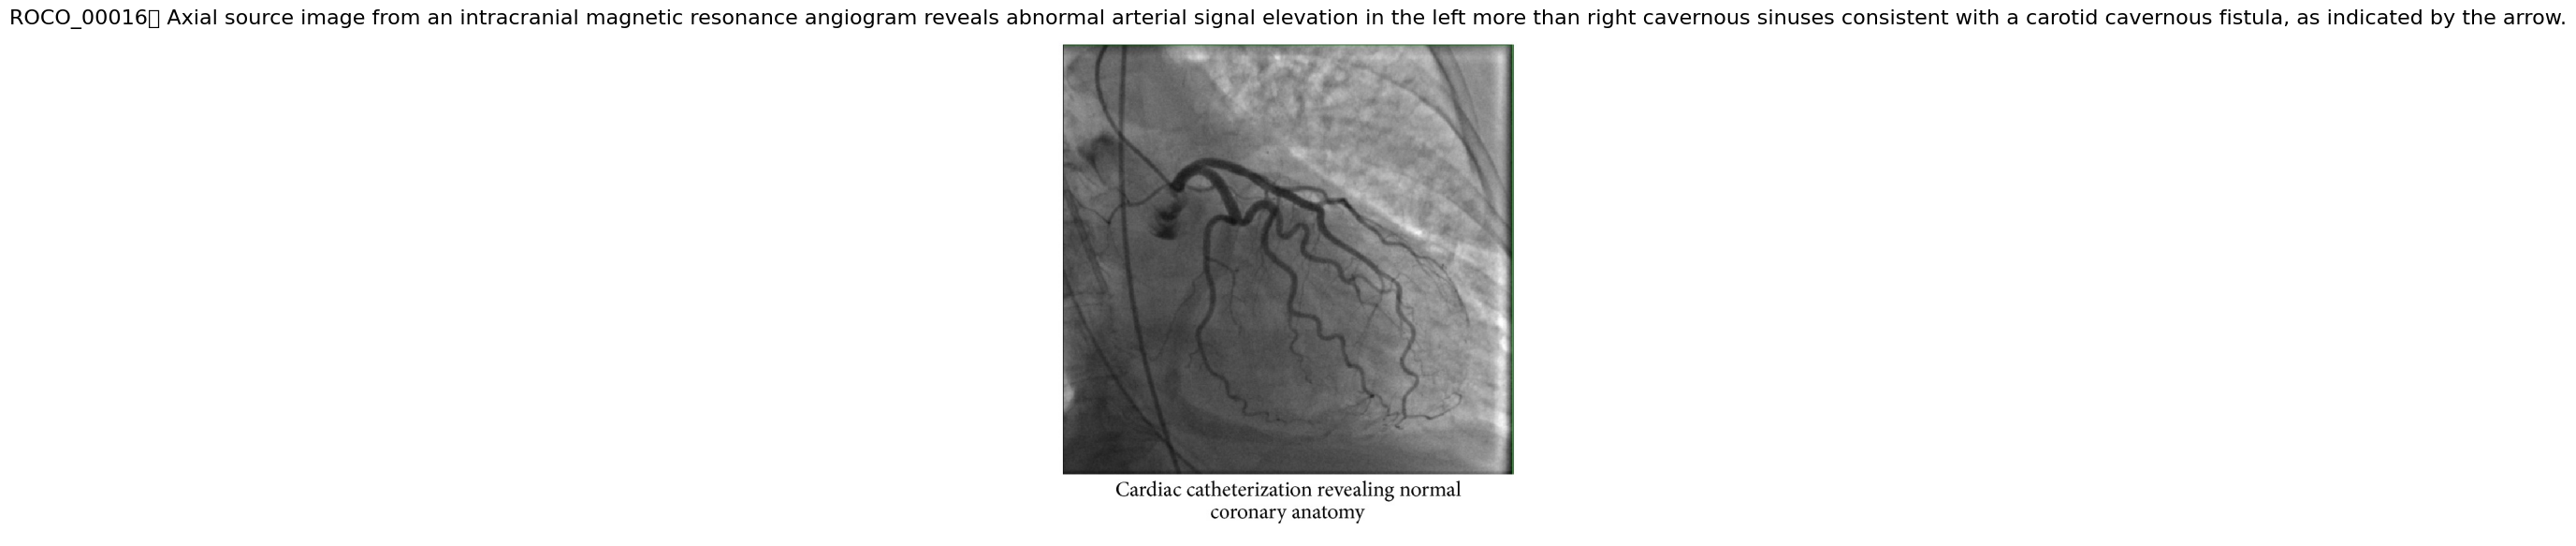

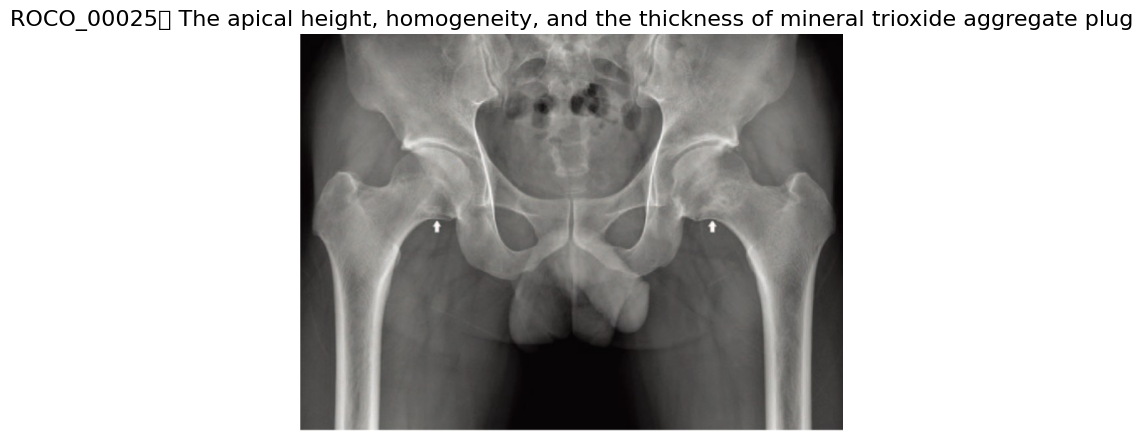

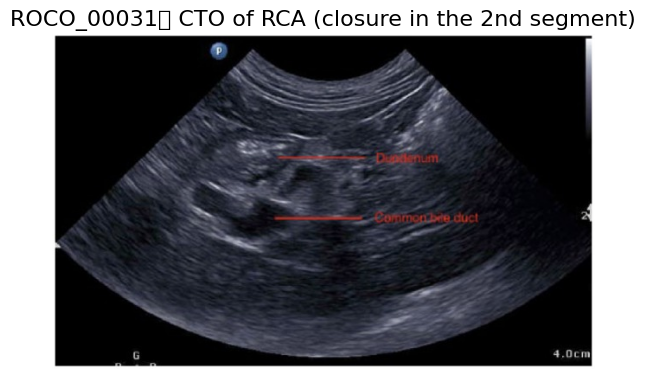

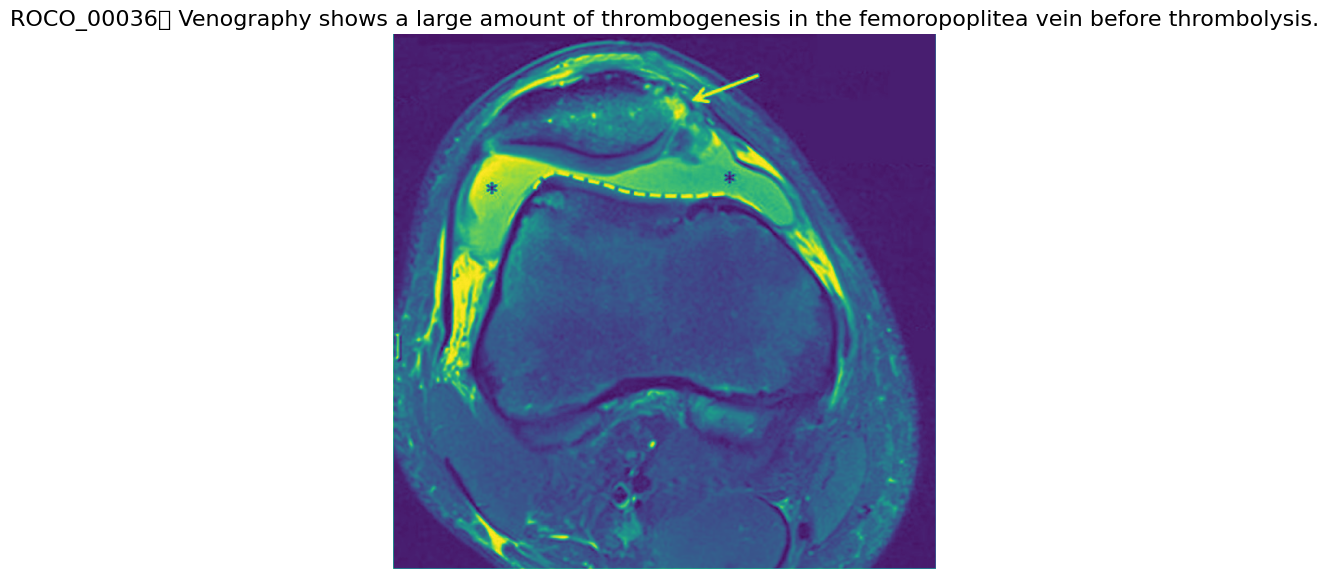

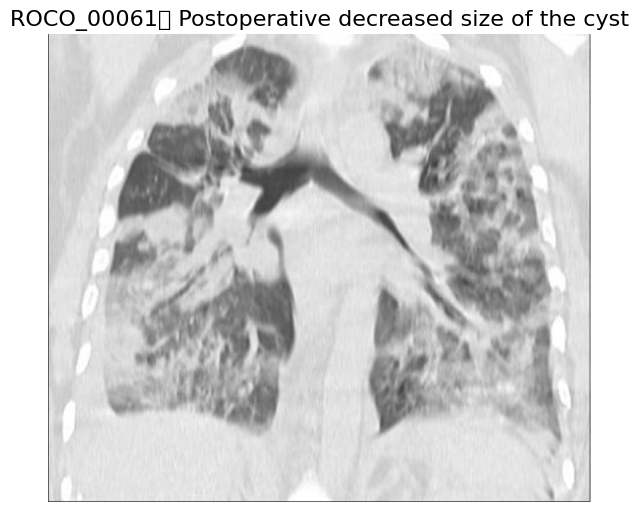

In [258]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Function to load images and captions
def load_images_and_captions(image_dir, captions_file, num_images=5):
    # Get all image file paths with supported extensions
    image_paths = [os.path.join(image_dir, filename) for filename in os.listdir(image_dir) if filename.endswith(('.jpg', '.png'))]

    # Read captions from file
    with open(captions_file, 'r', encoding='utf-8') as f:
        captions = [line.strip() for line in f]

    # Ensure equal lengths for images and captions
    min_len = min(len(image_paths), len(captions))
    image_paths = image_paths[:min_len]
    captions = captions[:min_len]

    # Limit to specified number of images
    return image_paths[:num_images], captions[:num_images]

# Function to display images with captions
def display_images_with_captions(image_paths, captions):
    for image_path, caption in zip(image_paths, captions):
        img = mpimg.imread(image_path)

        plt.figure(figsize=(7, 7))
        plt.imshow(img)
        plt.axis('off')
        plt.title(caption, fontsize=16)
        plt.show()

# Load and display images
num_images_to_display = 7
image_paths, captions = load_images_and_captions(image_path, caption_path, num_images=num_images_to_display)
display_images_with_captions(image_paths, captions)


In [259]:
def extract_features(image_path,model):
  img=tf.keras.preprocessing.image.load_img(image_path,target_size=(299,299))
  img=tf.keras.preprocessing.image.img_to_array(img)
  img=np.expand_dims(img,axis=0)
  img=preprocess_input(img)
  features=model.predict(img)
  return features


In [260]:
image_model=InceptionV3(weights="imagenet")
image_model=Model(inputs=image_model.input,outputs=image_model.layers[-2].output)

In [261]:
def preprocess_captions(captions):
  tokenizer=Tokenizer()
  tokenizer.fit_on_texts(captions)
  sequences=tokenizer.texts_to_sequences(captions)
  max_length=max(len(seq) for seq in sequences)
  vocab_size=len(tokenizer.word_index)+1
  return tokenizer,sequences,max_length,vocab_size

In [262]:
image_captions = {}
for filename in os.listdir(image_path):
  if filename.endswith(('.jpg', '.png')): # Check for image files
    full_path = os.path.join(image_path, filename)
    image_captions[full_path] = ["A caption for " + filename]

In [263]:
all_captions=[caption for captions in image_captions.values() for caption in captions]
tokenizer,sequences,max_length,vocab_size=preprocess_captions(all_captions)

In [264]:
sequences

[[1, 2, 3, 2493, 55, 82, 2494, 187, 4],
 [1, 2, 3, 2495, 154, 176, 656, 6, 4],
 [1, 2, 3, 2496, 420, 2497, 19, 4],
 [1, 2, 3, 2498, 741, 102, 140, 5, 4],
 [1, 2, 3, 2499, 15, 49, 2500, 30, 4],
 [1, 2, 3, 2501, 657, 8, 511, 5, 4],
 [1, 2, 3, 1386, 48, 95, 83, 107, 4],
 [1, 2, 3, 1387, 73, 90, 1388, 13, 4],
 [1, 2, 3, 2502, 65, 76, 10, 141, 8, 4],
 [1, 2, 3, 2503, 1389, 2504, 19, 4],
 [1, 2, 3, 2505, 368, 44, 2506, 59, 7, 4],
 [1, 2, 3, 1390, 78, 155, 421, 9, 4],
 [1, 2, 3, 1391, 69, 17, 42, 6, 4],
 [1, 2, 3, 2507, 110, 17, 137, 35, 4],
 [1, 2, 3, 2508, 28, 84, 176, 5, 4],
 [1, 2, 3, 2509, 317, 4],
 [1, 2, 3, 2510, 566, 208, 341, 5, 4],
 [1, 2, 3, 2511, 40, 4],
 [1, 2, 3, 2512, 55, 82, 2513, 187, 4],
 [1, 2, 3, 2514, 15, 49, 2515, 59, 4],
 [1, 2, 3, 2516, 73, 90, 2517, 6, 4],
 [1, 2, 3, 2518, 15, 49, 2519, 99, 4],
 [1, 2, 3, 2520, 1392, 2521, 36, 4],
 [1, 2, 3, 1393, 73, 90, 1394, 13, 4],
 [1, 2, 3, 1395, 422, 31, 38, 13, 4],
 [1, 2, 3, 2522, 369, 24, 874, 2523, 4],
 [1, 2, 3, 2524, 29, 

In [265]:
image_features={}

In [266]:
max_images = 14 # Number of images to process

# Iterate through image paths, but only for the first 10
for i, image_path in enumerate(image_captions):
    if i >= max_images:
        break
    image_features[image_path] = extract_features(image_path, image_model)

print(f"Extracted features for {len(image_features)} images.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
Extracted features for 14 images.


In [267]:
image_features

{'/content/drive/MyDrive/radiology/images/PMC5364092_cureus-0009-00000001052-i01.jpg': array([[0.30105203, 3.0457978 , 0.3575778 , ..., 0.70392865, 0.21325073,
         0.02400259]], dtype=float32),
 '/content/drive/MyDrive/radiology/images/PMC5368133_ymj-58-497-g002.jpg': array([[0.59754604, 0.03441324, 0.16413778, ..., 1.0631225 , 0.38330302,
         0.5256376 ]], dtype=float32),
 '/content/drive/MyDrive/radiology/images/PMC5359432_CRIC2017-8507096.002.jpg': array([[0.49026358, 0.14780685, 0.07492533, ..., 0.2873246 , 0.22033809,
         0.2180911 ]], dtype=float32),
 '/content/drive/MyDrive/radiology/images/PMC5352729_hp-29-77-g001.jpg': array([[0.12676257, 0.51982075, 0.45033264, ..., 0.37090594, 0.05447355,
         0.69314176]], dtype=float32),
 '/content/drive/MyDrive/radiology/images/PMC5361986_10.1177_2055116915610359-fig2.jpg': array([[0.27287078, 0.20444666, 0.12487345, ..., 0.92899096, 1.0700939 ,
         0.26945984]], dtype=float32),
 '/content/drive/MyDrive/radiology/i

In [268]:
def create_model(vocab_size,max_length):
  image_input=Input(shape=(2048,),name="image_input")
  image_dense=Dense(256,activation="relu",name="image_dense")(image_input)

  text_input=Input(shape=(max_length,))
  text_embedding=Embedding(vocab_size,256,mask_zero=True)(text_input)
  text_lstm=LSTM(256)(text_embedding)

  decoder=Add()([image_dense,text_lstm])
  decoder_dense=Dense(256,activation="relu")(decoder)
  output=Dense(vocab_size,activation="softmax")(decoder_dense)
  model=Model(inputs=[image_input,text_input],outputs=output)
  return model

In [269]:
model = create_model(vocab_size,max_length)
model.compile(loss="categorical_crossentropy",optimizer="adam")

In [270]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

def data_generator(image_features, image_captions, tokenizer, max_length, vocab_size):
    while True:
        for image_id, captions in image_captions.items():
            image_feature = image_features[image_id][0]  # Extract feature vector
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    input_seq = seq[:i]
                    output_word = seq[i]

                    # Pad the input sequence
                    input_seq = pad_sequences([input_seq], maxlen=max_length, padding='post')[0]

                    # Convert to tensors
                    image_feature_tensor = tf.convert_to_tensor(image_feature, dtype=tf.float32)
                    input_seq_tensor = tf.convert_to_tensor(input_seq, dtype=tf.float32)
                    output_word_tensor = tf.keras.utils.to_categorical([output_word], num_classes=vocab_size)[0]
                    output_word_tensor = tf.convert_to_tensor(output_word_tensor, dtype=tf.float32)

                    yield (image_feature_tensor, input_seq_tensor), output_word_tensor


In [271]:
dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(image_features, image_captions, tokenizer, max_length, vocab_size),
    output_signature=(
        (
            tf.TensorSpec(shape=(2048,), dtype=tf.float32),  # Image feature vector
            tf.TensorSpec(shape=(max_length,), dtype=tf.float32)  # Input sequence
        ),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)  # Target one-hot vector
    )
)


In [272]:
batch_size = 64
train_dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

#BLEU Score and ROUGE Metrics Calculation

In [273]:
!pip install nltk rouge

In [274]:
import nltk
from rouge import Rouge
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Load and preprocess captions
def load_captions(file, num_captions=7):
    with open(file, 'r') as f:
        captions = [line.strip() for line in f.readlines()[:num_captions]]
    return captions

# Calculate BLEU score
def calculate_bleu(reference, candidate):
    smooth_fn = SmoothingFunction().method1
    return sentence_bleu([reference.split()], candidate.split(), smoothing_function=smooth_fn)

# Calculate ROUGE scores
def calculate_rouge(reference, candidate):
    rouge = Rouge()
    scores = rouge.get_scores(candidate, reference)
    return scores[0]

# Example usage
caption_file = "/content/drive/MyDrive/radiology/captions.txt"
references = load_captions(caption_file, num_captions=7)
candidates = [
    "This is a sample generated caption.",
    "The radiology image shows a detailed structure.",
    "The generated text describes the image well.",
    "An example of caption for radiology data.",
    "Sample text for evaluation purpose.",
    "A generic caption for the given image.",
    "Generated text describing medical image."
]  # Replace with your generated captions

# Evaluate BLEU and ROUGE
for i, (ref, cand) in enumerate(zip(references, candidates)):
    bleu_score = calculate_bleu(ref, cand)
    rouge_score = calculate_rouge(ref, cand)
    print(f"Caption {i + 1}:")
    print(f"Reference: {ref}")
    print(f"Candidate: {cand}")
    print(f"BLEU Score: {bleu_score:.4f}")
    print(f"ROUGE Scores: {rouge_score}\n")


Caption 1:
Reference: ROCO_00001	 Axial MRI (coronal view).
Candidate: This is a sample generated caption.
BLEU Score: 0.0000
ROUGE Scores: {'rouge-1': {'r': 0.0, 'p': 0.0, 'f': 0.0}, 'rouge-2': {'r': 0.0, 'p': 0.0, 'f': 0.0}, 'rouge-l': {'r': 0.0, 'p': 0.0, 'f': 0.0}}

Caption 2:
Reference: ROCO_00006	 Coronal plain computed tomography image showing multiple large tumor masses with edge enhancement inside the abdominal cavity and liver.
Candidate: The radiology image shows a detailed structure.
BLEU Score: 0.0052
ROUGE Scores: {'rouge-1': {'r': 0.05, 'p': 0.14285714285714285, 'f': 0.07407407023319637}, 'rouge-2': {'r': 0.0, 'p': 0.0, 'f': 0.0}, 'rouge-l': {'r': 0.05, 'p': 0.14285714285714285, 'f': 0.07407407023319637}}

Caption 3:
Reference: ROCO_00016	 Axial source image from an intracranial magnetic resonance angiogram reveals abnormal arterial signal elevation in the left more than right cavernous sinuses consistent with a carotid cavernous fistula, as indicated by the arrow.
Candi

In [275]:
caption_file = "/content/drive/MyDrive/radiology/captions.txt"

In [276]:
import nltk
from rouge import Rouge
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Load and preprocess captions
def load_captions(caption_file, num_captions=7):
    with open(caption_file, 'r') as f:
        captions = [line.strip() for line in f.readlines()[:num_captions]]
    return captions

def rmse_scorer(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# RandomizedSearchCV
def random_search(X, y):
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('ridge', Ridge())
    ])
    params = {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
        'tfidf__max_features': [1000, 2000, 3000]
    }

    # Create the RandomizedSearchCV object with RMSE scorer
    scorer = make_scorer(rmse_scorer, greater_is_better=False)  # RMSE should be minimized
    search = RandomizedSearchCV(pipeline, param_distributions=params, scoring=scorer, n_iter=5, cv=3,
                                random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(captions, y, test_size=0.2, random_state=42)
    search.fit(X, y)

    return search.best_params_

# Example usage
caption_file = "/content/drive/MyDrive/radiology/captions.txt"
captions = load_captions(caption_file)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(captions)  # Convert captions to numerical labels

# Call random_search with features (X) and encoded captions (y_encoded)
print("RandomSearchCV Best Params:", random_search(captions, y_encoded))

RandomSearchCV Best Params: {'tfidf__max_features': 1000, 'ridge__alpha': 0.01}


In [277]:
# GridSearchCV
def grid_search(X, y):
    pipeline = Pipeline([  # Create a pipeline with TfidfVectorizer
        ('tfidf', TfidfVectorizer()),
        ('ridge', Ridge())
    ])
    params = {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
        'tfidf__max_features': [1000, 2000, 3000]  # Add parameters for TfidfVectorizer
    }

    # Define the bleu_score_scorer function
    def bleu_score_scorer(y_true, y_pred):
        smooth_fn = SmoothingFunction().method1
        y_true_decoded = label_encoder.inverse_transform(y_true.astype(int))  # Correctly inverse transform
        y_pred_decoded = label_encoder.inverse_transform(y_pred.astype(int))  # Correctly inverse transform
        bleu_scores = []
        for true_caption, pred_caption in zip(y_true_decoded, y_pred_decoded):
            bleu_scores.append(sentence_bleu([true_caption.split()], pred_caption.split(), smoothing_function=smooth_fn))
        return np.mean(bleu_scores)  # Return average BLEU score

    scorer = make_scorer(bleu_score_scorer, greater_is_better=True)  # Specify that higher scores are better
    search = GridSearchCV(pipeline, param_grid=params, scoring=scorer, cv=3)  # Use pipeline in GridSearchCV
    search.fit(X, y)  # Fit with captions (X) and encoded labels (y)
    return search.best_params_

# Example usage
caption_file = "/content/drive/MyDrive/radiology/captions.txt"
captions = load_captions(caption_file)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(captions)  # Convert captions to numerical labels

# Call grid_search with captions (X) and encoded captions (y_encoded)
print("GridSearchCV Best Params:", grid_search(captions, y_encoded))

GridSearchCV Best Params: {'ridge__alpha': 0.01, 'tfidf__max_features': 1000}
